In [5]:
%pip install numpy seaborn matplotlib pandas pillow tqdm scikit-learn torch torchvision backpack-for-pytorch opt_einsum


[notice] A new release of pip is available: 23.3.1 -> 25.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [6]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
import sys


N_up = 2
nb_dir = '/'.join(os.getcwd().split('/')[:-N_up])
if nb_dir not in sys.path:
    sys.path.append(nb_dir)
N_up = 1
nb_dir = '/'.join(os.getcwd().split('/')[:-N_up])
if nb_dir not in sys.path:
    sys.path.append(nb_dir)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
import os
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

# Step #0: Define Experimental Setup

In [8]:
from pathlib import Path
import time



# general
device = "cuda:0"
model_name = "resnet18"
dataset = "MNIST"
# train_batch_size = 512
# laplace_batch_size = 128
# test_batch_size = 256
train_batch_size = 256
laplace_batch_size = 32
test_batch_size = 128
n_test_data = None
# rotations = [0, 30, 60, 90, 120, 150, 180]
rotations = [0] #updated_sd
n_out = 10
loss = "cross_entropy"

# paths
data_dir = "./data"
root_dir = Path(f"./{model_name}_{dataset}")
ggn_dir = root_dir / "ggn.pt"

# subnetwork selection
n_weights_subnet = 5000 #updated_sd
subnet_selection = "min-wass" # "magnitude", "min-wass", "random"

# prediction
pred_lambda = 42.

# Step #1: Train or Load Model

In [16]:
from src.scripts.train_classification import train_loop
from src.utils import list_batchnorm_layers, get_n_params, model_to_device, instantiate_model

start_time=time.time()
model = model_to_device(instantiate_model(model_name, dataset, 0.1), device)
bn_layers = list_batchnorm_layers(model)
print('Nparams:', get_n_params(model, bn_layers))

gpu = 0
train_loop(model, dname=dataset, data_dir=data_dir, epochs=10, workers=4, gpu=gpu, resume=str(root_dir / 'model_best.pth.tar'),
            weight_decay=1e-4, save_dir=str(root_dir), milestones=[10, 17], MC_samples=1, batch_size=train_batch_size)

end_time=time.time()
mins_elapsed= round((end_time-start_time)/60, 2)
print(f"{mins_elapsed} mins elapsed...")

Nparams: 11163200
Use GPU: 0 for training
=> loading checkpoint 'resnet18_MNIST/model_best.pth.tar'
=> loaded checkpoint 'resnet18_MNIST/model_best.pth.tar' (epoch 2)
=> found progress file at 'resnet18_MNIST/stats_array.pkl'
=> Loaded progress file at 'resnet18_MNIST/stats_array.pkl'
Ntrain: 60000, Nval: 10000


  2%|▏         | 2/118 [00:00<00:24,  4.70it/s]

Epoch: [2][  0/118]	Time  0.341 ( 0.341)	Data  0.218 ( 0.218)	Loss 7.1296e-02 (7.1296e-02)	Acc@1  97.46 ( 97.46)	Acc@5  99.80 ( 99.80)


 36%|███▌      | 42/118 [00:05<00:09,  8.06it/s]

Epoch: [2][ 40/118]	Time  0.124 ( 0.129)	Data  0.001 ( 0.006)	Loss 5.8079e-02 (8.2762e-02)	Acc@1  98.24 ( 97.50)	Acc@5 100.00 ( 99.92)


...

 69%|██████▉   | 82/118 [00:10<00:04,  7.91it/s]

Epoch: [9][ 80/118]	Time  0.126 ( 0.129)	Data  0.001 ( 0.004)	Loss 5.8948e-02 (2.4119e-02)	Acc@1  98.24 ( 99.31)	Acc@5 100.00 ( 99.99)


100%|██████████| 118/118 [00:15<00:00,  7.83it/s]

used lr: 0.100000


Test: [ 0/20]	Time  0.222 ( 0.222)	Loss 4.7365e-02 (4.7365e-02)	Acc@1  98.24 ( 98.24)	Acc@5 100.00 (100.00)
 * Acc@1 98.740 Acc@5 99.990
Saving to resnet18_MNIST/checkpoint.pth.tar
2.16 mins elapsed...


# Step #2: Select Subnetwork

In [17]:
from src.datasets.image_loaders import get_image_loader
from src.utils import print_nonzeros
from src.masking.masking import random_mask, smallest_magnitude_mask, wasserstein_mask

start_time=time.time()

# compute subnetwork mask
if n_weights_subnet == None:
    mask = None

elif subnet_selection == "random":
    mask, index_mask, weight_score_vec = random_mask(model, bn_layers, n_weights_subnet, device=device)

elif subnet_selection == "min-wass":
    train_loader = get_image_loader(dataset, batch_size=train_batch_size, cuda=True, workers=2, distributed=False, data_dir=data_dir)[1]
    mask, index_mask, weight_score_vec = wasserstein_mask(model, bn_layers, n_weights_subnet, train_loader, device)

elif subnet_selection == "magnitude":
    mask, index_mask, weight_score_vec = smallest_magnitude_mask(model, bn_layers, n_weights_subnet)
    
else:
    raise NotImplementedError("Supported subnetwork selection methods: random, min-wass, magnitude.")

if mask is not None:
    # print mask information
    print_nonzeros(mask)

end_time=time.time()
mins_elapsed= round((end_time-start_time)/60, 2)
print(f"{mins_elapsed} mins elapsed...")

Ntrain: 60000, Nval: 10000


100%|██████████| 256/256 [1:03:46<00:00, 14.95s/it]


conv1.0.weight                      | remaining =     157 /     576 ( 27.26%) | pruned =     419 | shape = torch.Size([64, 1, 3, 3])
layer_list.0.conv1.weight           | remaining =     184 /   36864 (  0.50%) | pruned =   36680 | shape = torch.Size([64, 64, 3, 3])
layer_list.0.conv2.weight           | remaining =     175 /   36864 (  0.47%) | pruned =   36689 | shape = torch.Size([64, 64, 3, 3])
layer_list.1.conv1.weight           | remaining =     135 /   36864 (  0.37%) | pruned =   36729 | shape = torch.Size([64, 64, 3, 3])
layer_list.1.conv2.weight           | remaining =     115 /   36864 (  0.31%) | pruned =   36749 | shape = torch.Size([64, 64, 3, 3])
layer_list.2.conv1.weight           | remaining =       4 /   73728 (  0.01%) | pruned =   73724 | shape = torch.Size([128, 64, 3, 3])
layer_list.2.conv2.weight           | remaining =       9 /  147456 (  0.01%) | pruned =  147447 | shape = torch.Size([128, 128, 3, 3])
layer_list.2.downsample.0.weight    | remaining =    1428 / 

# Step #3: Do Linearized Laplace Inference

In [20]:
from src.laplace.laplace import Laplace
from src.datasets.image_loaders import get_image_loader
import torch

laplace_batch_size = 32 #updated_sd

start_time=time.time()

# instantiate Laplace model
laplace_dir = root_dir / f"laplace.pth.tar"
laplace_model = Laplace(model, mask=mask, index_mask=index_mask, save_path=laplace_dir, device=device, loss=loss, n_out=n_out)

# load or fit Hessian approximation
if ggn_dir.exists():
    print("Loading GGN from disk...")
    laplace_model.H = torch.load(ggn_dir)

elif laplace_dir.exists():
    print("Loading Laplace model from disk...")
    laplace_model.load()

else:
    print(f"Computing Hessian/GGN...")
    train_loader = get_image_loader(dataset, batch_size=laplace_batch_size, cuda=True, workers=2, distributed=False, data_dir=data_dir)[1]
    laplace_model.fit_laplace(train_loader)

end_time=time.time()
mins_elapsed= round((end_time-start_time)/60, 2)
print(f"{mins_elapsed} mins elapsed...")

Computing Hessian/GGN...
Ntrain: 60000, Nval: 10000


  0%|          | 0/1875 [00:00<?, ?it/s]

37.56 mins elapsed...


# Step #4: Make Predictions

In [21]:
import numpy as np

results_path = root_dir / "results.npy"
if results_path.exists():
    results_dict = np.load(results_path, allow_pickle=True).item()
else:
    results_dict = {}

In [22]:
import numpy as np

from src.evaluation.evaluate_laplace import evaluate_laplace
from src.evaluation.evaluate_baselines import evaluate_map

methods = ["MAP", "subnetwork_inference"]
test_batch_size = 16 #updated_sd
rotations = [0, 30, 60, 90, 120, 150, 180] #updated_sd

start_time=time.time()

# compute error, log-likelihood, Brier score and ECE on shifted test data
for method in methods:
    for rot in rotations:
        if method in results_dict and rot in results_dict[method]:
            continue
        elif method not in results_dict:
            results_dict[method] = {}

        print(f"Computing predictions for {method} at rotation={rot}...")
        
        if method == "MAP":
            results_dict[method][rot] = evaluate_map(model, dataset, data_dir, device, loss, corruption=None,
                                                    rotation=rot, batch_size=test_batch_size, n_test_data=n_test_data)
        else:
            results_dict[method][rot] = evaluate_laplace(laplace_model, dataset, data_dir, corruption=None, rotation=rot, 
                                                        batch_size=test_batch_size, λ=pred_lambda, n_test_data=n_test_data)

# save result dictionary
np.save(results_path, results_dict)

end_time=time.time()
mins_elapsed= round((end_time-start_time)/60, 2)
print(f"{mins_elapsed} mins elapsed...")

Computing predictions for MAP at rotation=0...


100%|██████████| 625/625 [00:02<00:00, 218.98it/s]
/workspace/subnetwork_inference/src/evaluation/utils.py:61: RuntimeWarning: Mean of empty slice.
  reference = np.array([expanded_preds[bin_idxs == nbin].mean() for nbin in range(n_bins)])
/usr/local/lib/python3.10/dist-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


Computing predictions for MAP at rotation=30...


100%|██████████| 625/625 [00:02<00:00, 228.11it/s]


Computing predictions for MAP at rotation=60...


...

Computing predictions for subnetwork_inference at rotation=150...
Computing covariance matrix...


  0%|          | 0/625 [00:00<?, ?it/s]

Computing predictions for subnetwork_inference at rotation=180...
Computing covariance matrix...


  0%|          | 0/625 [00:00<?, ?it/s]

49.87 mins elapsed...


# Step #5: Plot Results

In [ ]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# start_time=time.time()

# methods_to_plot = ["MAP", "subnetwork_inference"]

# metrics = results_dict[methods_to_plot[0]][rotations[0]].keys()

# fig, axes = plt.subplots(4, 1, figsize = (6, 15), dpi=400)
# axes[0].set_title(f"{model_name} on {dataset} with {subnet_selection} subnetwork")

# xs = list(results_dict[methods_to_plot[0]].keys())
# for metric, axis in zip(metrics, axes):
#     for method in methods_to_plot:
#         ys = [results_dict[method][rot][metric] for rot in results_dict[method]]
#         axis.plot(xs, ys, label=method)
#     axis.set_ylabel(metric)
#     axis.set_xlabel("rotation")
#     axis.legend(prop={'size': 6})

# plt.show()

# end_time=time.time()
# mins_elapsed= round((end_time-start_time)/60, 2)
# print(f"{mins_elapsed} mins elapsed...")

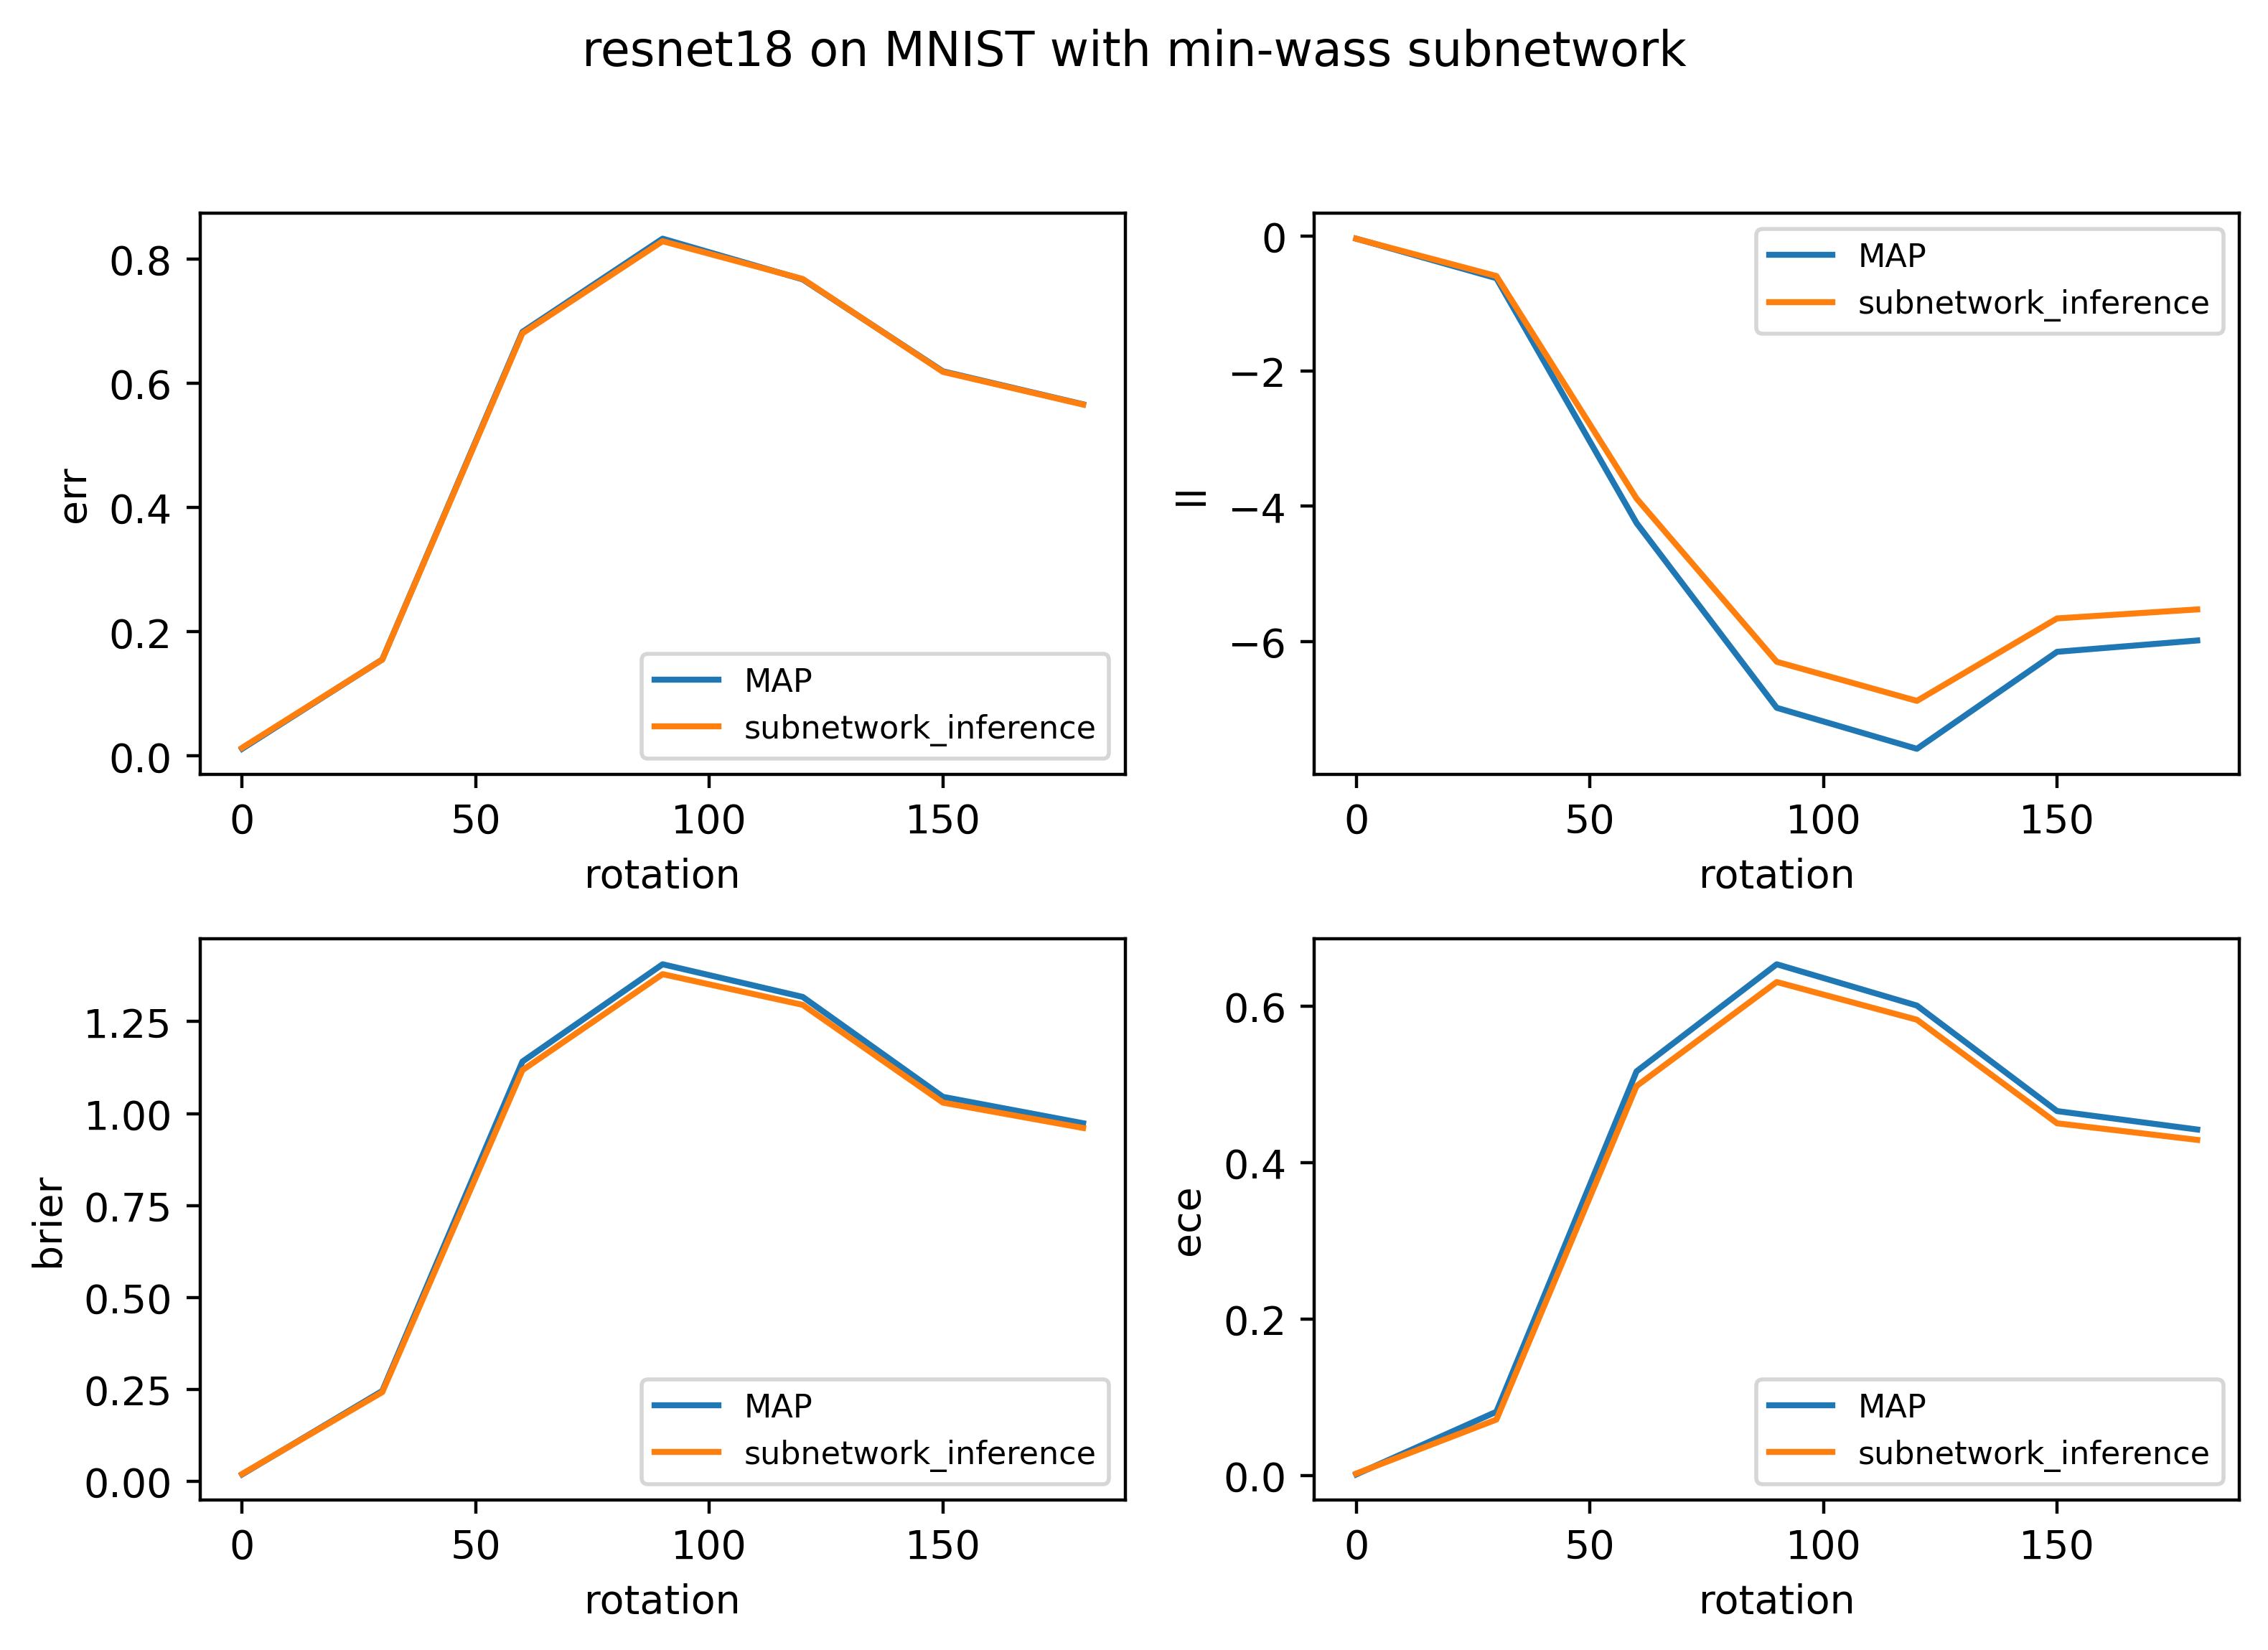

0.01 mins elapsed...


In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

methods_to_plot = ["MAP", "subnetwork_inference"]
# results_dict = res_dict.copy()
start_time=time.time()

if 'model_name' not in locals():
    model_name = "ResNet18"
if 'dataset' not in locals():
    dataset = "CIFAR10"
if 'subnet_selection' not in locals():
    subnet_selection = "random"
if 'rotations' not in locals():
    rotations = list(results_dict[methods_to_plot[0]].keys())

metrics = list(results_dict[methods_to_plot[0]][rotations[0]].keys())

fig, axes = plt.subplots(2, 2, figsize=(8, 6), dpi=400)
fig.suptitle(f"{model_name} on {dataset} with {subnet_selection} subnetwork")
axes = axes.flatten() # Flatten the 2x2 array of axes for easy iteration

xs = list(results_dict[methods_to_plot[0]].keys())
for i, metric in enumerate(metrics):
    ax = axes[i]
    for method in methods_to_plot:
        ys = [results_dict[method][rot][metric] for rot in results_dict[method]]
        ax.plot(xs, ys, label=method)
    ax.set_ylabel(metric)
    ax.set_xlabel("rotation")
    ax.legend(prop={'size': 8})

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent overlap and make space for suptitle
plt.show()

end_time=time.time()
mins_elapsed= round((end_time-start_time)/60, 2)
print(f"{mins_elapsed} mins elapsed...")